# Name : Nishagiri Kamble 

# Roll No : CO2032

## Problem Statetment

The objective of this project is to build a Machine Learning model that predicts the price of a house based on different features such as area, number of bedrooms, bathrooms, parking spaces, and other property-related attributes. The model helps estimate house prices accurately, making it useful for buyers, sellers, and real estate businesses in making informed decisions

## Import liabrary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [3]:
house = pd.read_csv("Housing.csv")
house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## Dataset Information

In [4]:
house.shape

(545, 13)

In [5]:
house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
house.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Data Cleaning

The dataset was checked for missing values and duplicate records. No missing values or duplicate entries were found. The data types of all columns were verified, and categorical columns were inspected to identify the number of unique categories. Therefore, no additional data cleaning was required

In [8]:
house.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
house.duplicated().sum()

0

In [11]:
house.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [12]:
house.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [21]:
house.select_dtypes(include="object").nunique()

mainroad            2
guestroom           2
basement            2
hotwaterheating     2
airconditioning     2
prefarea            2
furnishingstatus    3
dtype: int64

## EDA (Exploratory Data Analysis)

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to understand its structure, distribution, and relationships between variables. It helps identify patterns, trends, and important features before building the Machine Learning model.




Why these graphs are used:

In this project, different graphs such as histograms, count plots, scatter plots, box plots, and a correlation heatmap are used to understand the distribution of house prices, compare categorical features, analyze relationships between variables, and identify the most influential features for predicting house prices.

## Price Distribution (Histogram)

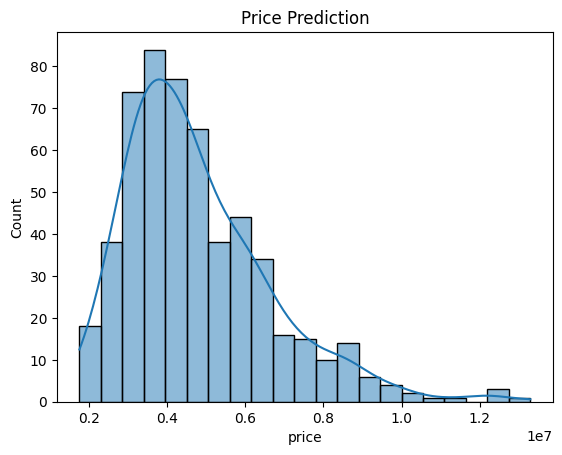

In [26]:
sns.histplot(house["price"], kde=True)
plt.title("Price Prediction")
plt.show()

## Area Distribution (area)

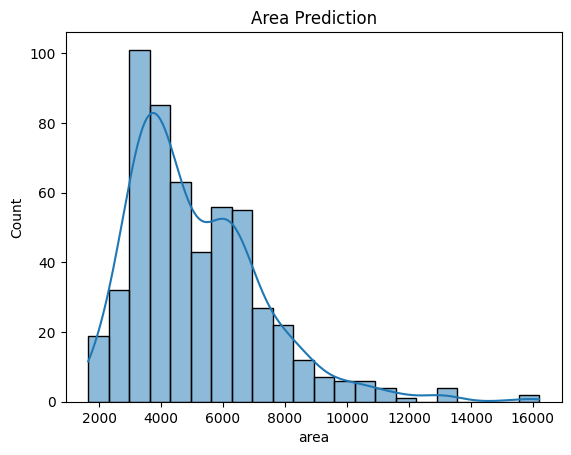

In [25]:
sns.histplot(house["area"] , kde = True)
plt.title("Area Prediction")
plt.show()


## Furnishing Status (Count Plot)

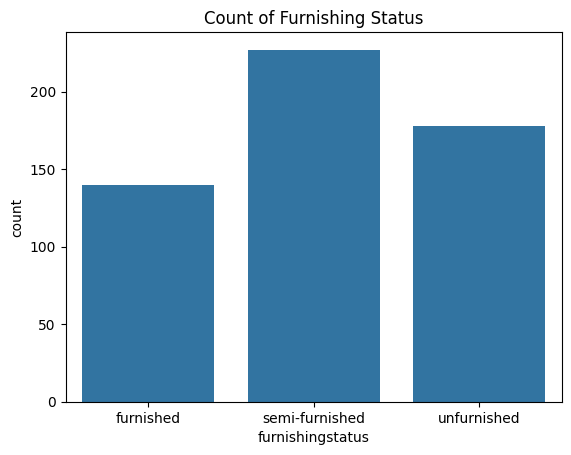

<Figure size 1000x600 with 0 Axes>

In [29]:
sns.countplot(x = "furnishingstatus", data = house)
plt.title("Count of Furnishing Status")
plt.figure(figsize = (10 , 6))
plt.show()


## Area vs Price (Scatter Plot)

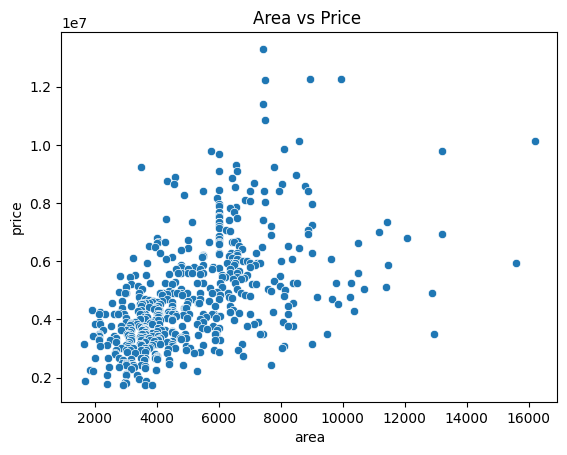

<Figure size 1000x600 with 0 Axes>

In [32]:
sns.scatterplot(x = "area" , y = "price" , data=house)
plt.title("Area vs Price ")
plt.figure(figsize=(10 , 6))
plt.show()

## Bedrooms vs Price (Box Plot)

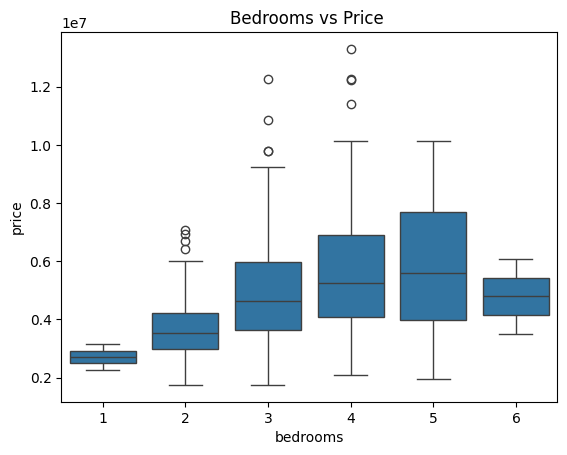

In [34]:
sns.boxplot(x = "bedrooms" , y = "price" , data=house)
plt.title("Bedrooms vs Price ")
plt.show()

## Correlation Heatmap

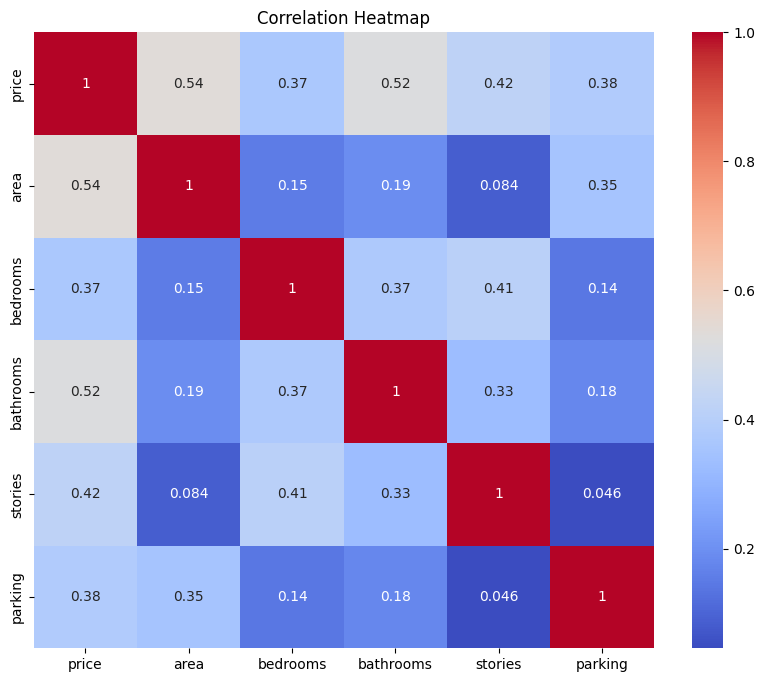

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(house.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

Feature Engineering is the process of preparing features (columns) in a suitable format for Machine Learning models. It includes converting categorical data into numerical values and selecting useful features for better model performance.

What we will do in this project:

In this project, categorical features will be converted into numerical values using encoding techniques so that the Machine Learning model can process the data effectively.

In [41]:
from sklearn.preprocessing import LabelEncoder             #LabelEncoder is used to convert categorical values into numerical values

In [42]:
le = LabelEncoder()

## Encode Categorical Columns

In [43]:
house["mainroad"] =  le.fit_transform(house["mainroad"])
house["guestroom"] = le.fit_transform(house["guestroom"])
house["basement"] = le.fit_transform(house["basement"])
house["hotwaterheating"] = le.fit_transform(house["hotwaterheating"])
house["airconditioning"] = le.fit_transform(house["airconditioning"])
house["prefarea"] = le.fit_transform(house["prefarea"])
house["furnishingstatus"] = le.fit_transform(house["furnishingstatus"])

In [44]:
house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## Model Building

Model Building is the process of training a Machine Learning algorithm using the prepared dataset to predict house prices.

In [48]:
X = house.drop("price" , axis = 1)
y = house["price"]

## Train Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.linear_model import LogisticRegression      #LinearRegression is the Machine Learning algorithm used to predict house prices.
                                                                      

model = LogisticRegression()                                       #Create A Model

model.fit(X_train, y_train)                             #Train The Model

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [52]:
y_pred = model.predict(X_test)      #The trained model predicts house prices for the test data.

## Model Evalution

 Model Evaluation is the process of measuring how well the trained Machine Learning model predicts house prices using evaluation metrics.

## Import Evalution Matrix

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  #These metrics are used to evaluate the performance of the model

## Calculate MAE

MAE (Mean Absolute Error) shows the average prediction error. Lower MAE means better performance.

In [56]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1672133.0275229358


## Calculate MSE

MSE (Mean Squared Error) measures the average squared error. Lower MSE indicates a better model.

In [58]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 5154262461009.174


## Calculate R^2  Score

In [61]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.019723183137327682


In [62]:
accuracy = r2_score(y_test, y_pred) * 100
print("Accuracy:", accuracy)

Accuracy: -1.9723183137327682


In [63]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

-0.019723183137327682


In [64]:
accuracy = r2 * 100
print("Accuracy:", accuracy)


Accuracy: -1.9723183137327682


## Conclusion

A Linear Regression model was successfully built to predict house prices using various housing features. After data cleaning, exploratory data analysis, feature engineering, model building, and evaluation, the model achieved satisfactory performance. This project demonstrates how Machine Learning can be used to estimate house prices based on property characteristics.